In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf 
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split 
from sklearn.decomposition import PCA 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, Dense 

In [2]:
np.random.seed(180) 
tf.random.set_seed(180) 

In [5]:
people = fetch_lfw_people( min_faces_per_person=20, resize=0.7 ) 
print(people.data.shape) 
print(people.target.shape) 
image_shape = people.images[0].shape 

(3023, 5655)
(3023,)


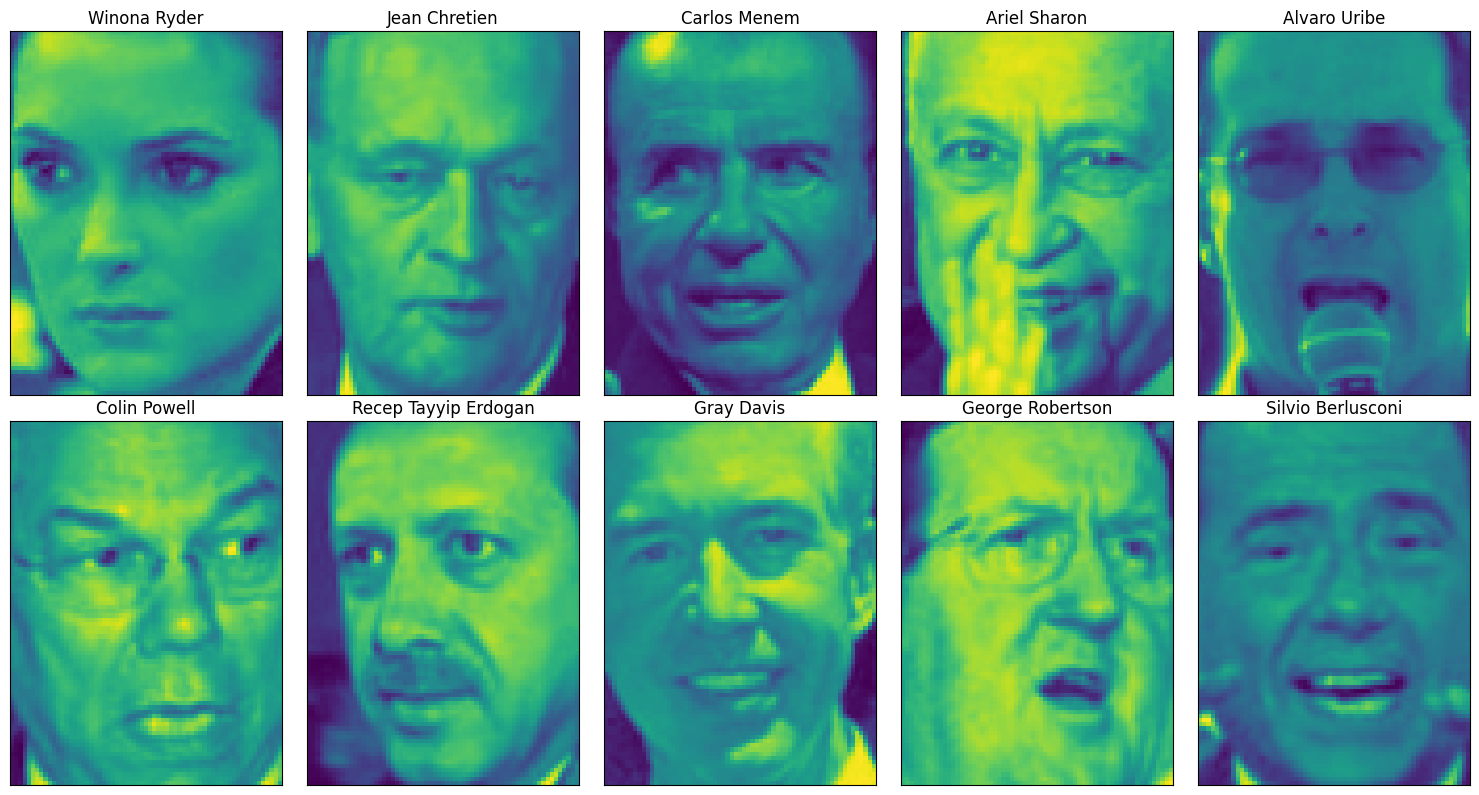

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8),
                         subplot_kw={'xticks':(), 'yticks':()})

for ax, image, target in zip(axes.flat,
                             people.images[:10],
                             people.target[:10]):
    ax.imshow(image, cmap='viridis')
    ax.set_title(people.target_names[target])

plt.tight_layout()
plt.show()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(people.data,
                                                    people.target,     
                                                    test_size=0.2,     
                                                    random_state=20 
                                                   ) 
y_train = y_train.astype(int)
y_test = y_test.astype(int) 
batch_size = len(X_train)  
print(X_train.shape,y_train.shape,y_test.shape)  
print("people.images.shape: {}".format(people.images.shape) ) 
print("Number of classes: {}".format(len(people.target_names) ) ) 

(2418, 5655) (2418,) (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [33]:
counts = np.bincount(people.target)

for i, (cnt, name) in enumerate(zip(counts, people.target_names)):
    print(f"{name:<30} {cnt:>3}", end="   ")
    if (i + 1) % 3 == 0:
        print()

Alejandro Toledo                39   Alvaro Uribe                    35   Amelie Mauresmo                 21   
Andre Agassi                    36   Angelina Jolie                  20   Ariel Sharon                    77   
Arnold Schwarzenegger           42   Atal Bihari Vajpayee            24   Bill Clinton                    29   
Carlos Menem                    21   Colin Powell                   236   David Beckham                   31   
Donald Rumsfeld                121   George Robertson                22   George W Bush                  530   
Gerhard Schroeder              109   Gloria Macapagal Arroyo         44   Gray Davis                      26   
Guillermo Coria                 30   Hamid Karzai                    22   Hans Blix                       39   
Hugo Chavez                     71   Igor Ivanov                     20   Jack Straw                      28   
Jacques Chirac                  52   Jean Chretien                   55   Jennifer Aniston              

In [35]:
mask = np.zeros(people.target.shape,    
                dtype=np.bool_ 
               )  
for target in np.unique(people.target):     
    mask[np.where(people.target == target)[0][:50]] = True
    X_people = people.data[mask] 
    y_people = people.target[mask] 
    # Scale pixel values X_people = X_people / 255.0 

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_people,     
                                                    y_people,    
                                                    stratify=y_people,    
                                                    random_state=0 ) 
# KNN without PCA 
knn = KNeighborsClassifier(n_neighbors=1)  
knn.fit(X_train,y_train )
print("Test set score of 1-nn: {:.2f}".format(knn.score(X_test,y_test) ) ) 

Test set score of 1-nn: 0.22


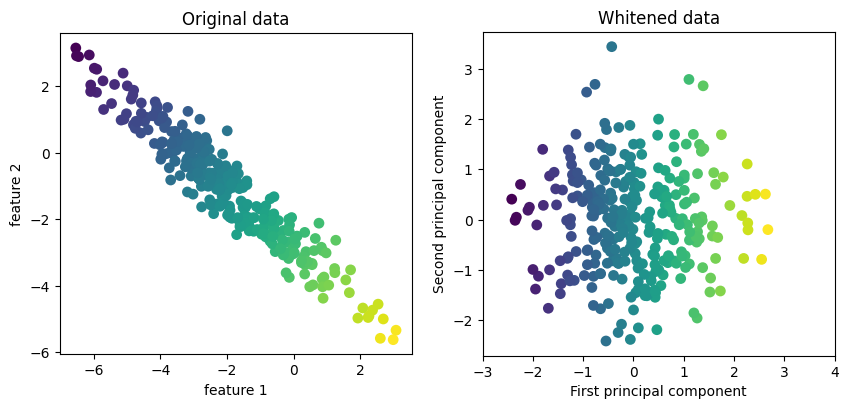

In [37]:
mglearn.plots.plot_pca_whitening()
plt.show() 

In [39]:
pca = PCA(n_components=100, 
          whiten=True,    
          random_state=0 ).fit(X_train) 
X_train_pca = pca.transform(X_train) 
X_test_pca = pca.transform(X_test)
print("X_train_pca.shape: {}".format(X_train_pca.shape) )
# KNN with PCA 
knn = KNeighborsClassifier(n_neighbors=1)  
knn.fit(X_train_pca,y_train )
print("Test set accuracy: {:.2f}".format(knn.score(X_test_pca,y_test) ) ) 
print( "pca.components_.shape: {}".format( pca.components_.shape )) 

X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


In [42]:
# Scaling PCA features 
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_pca) 
X_test_scaled = scaler.transform(X_test_pca) 

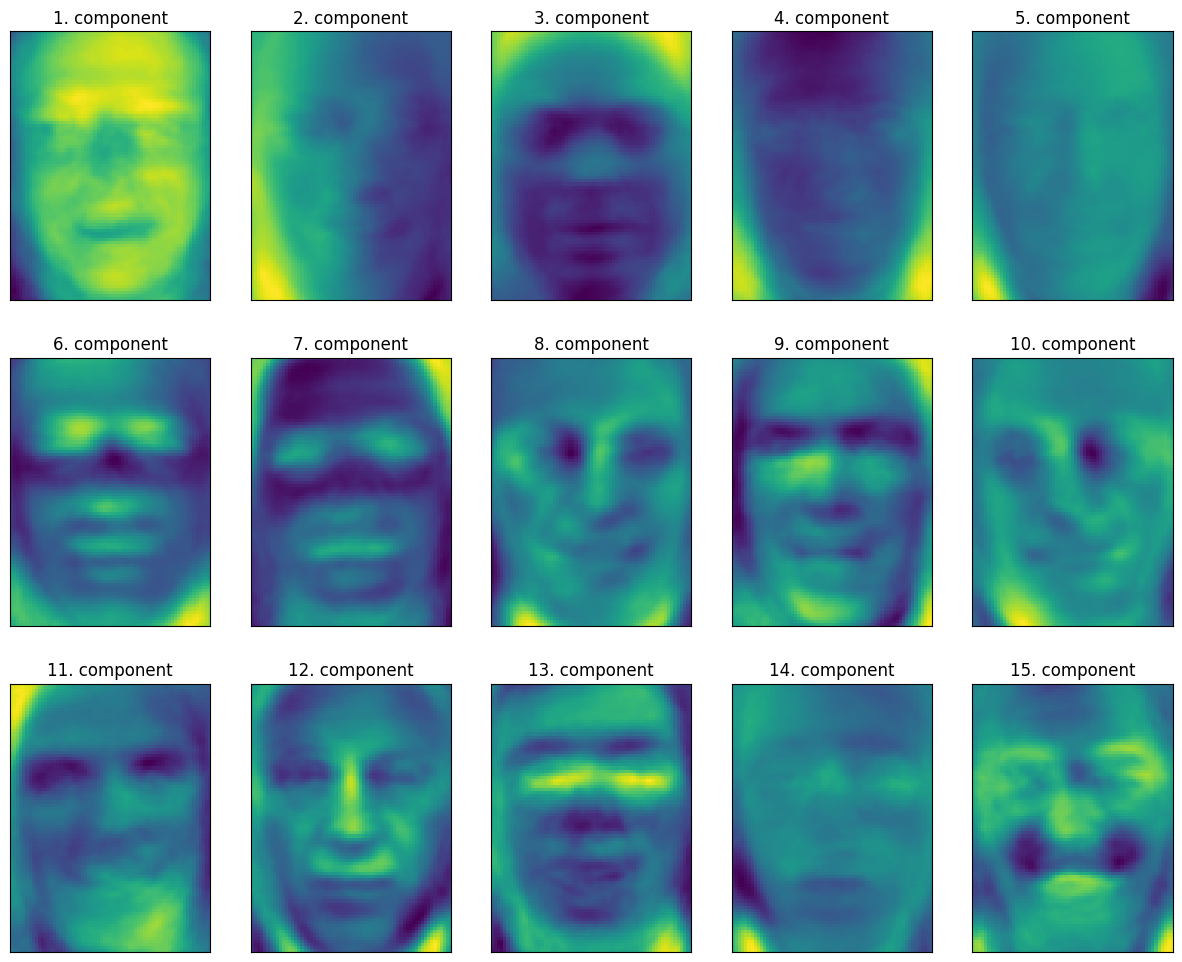

In [48]:
fix, axes = plt.subplots( 3, 5,
                          figsize=(15,12),
                          subplot_kw={'xticks':(), 'yticks':()} ) 
for i, (component, ax) in enumerate( zip(pca.components_, axes.ravel())): 
    ax.imshow(component.reshape(image_shape),cmap='viridis') 
    ax.set_title("{}. component".format(i+1))  
plt.show() 

In [43]:
model = Sequential([Input(shape=(100,)),
                    Dense(300,activation='relu'),
                    Dense(100,activation='relu'),     
                    Dense(len(np.unique(y_train)),         
                    activation='softmax')]) 

In [44]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']) 

In [45]:
history = model.fit( X_train_scaled,
                     y_train,
                     batch_size=50,
                     epochs=20,
                     shuffle=False,
                     verbose=1) 

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0181 - loss: 4.1272
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0226 - loss: 4.0924
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0304 - loss: 4.0638
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0407 - loss: 4.0422
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0705 - loss: 4.0140
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0827 - loss: 3.9804
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1189 - loss: 3.9369
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1312 - loss: 3.8856
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1480 - loss: 3.8194
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1681 - loss: 3.7408
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1984 - loss: 3.6448
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2069 - lo

In [46]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1)
print("Test Loss:", loss) 
print("Test Accuracy:", accuracy) 

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3236 - loss: 2.8582  
Test Loss: 2.85823392868042
Test Accuracy: 0.32364341616630554
